<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/Day4/U9_EDA_Statistical_Analysis_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Connect Google Drive

We first mount Google Drive so that Colab can access files stored in our Drive.

After running the code, click the authorization link and grant permission.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Step 2: Specify Dataset Location

After mounting Drive, provide the path to the dataset.

Example:

MyDrive/
    ML_Lab/
        ecommerce_customers.csv

In [2]:
import pandas as pd

file_path = "/content/drive/MyDrive/ecommerce_customers.csv"

df = pd.read_csv(
    file_path,
    parse_dates=[
        'signup_date',
        'first_order_date',
        'last_order_date'
    ]
)

print("Dataset Loaded Successfully")
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Dataset Loaded Successfully
Rows : 2500
Columns : 15


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [4]:
transactions_path = "/content/drive/MyDrive/transactions.xlsx"

tx = pd.read_excel(transactions_path)

print("Transactions Dataset Loaded")
print(tx.shape)

tx.head()

Transactions Dataset Loaded
(8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


# Step 3: Verify Dataset Structure

Before starting EDA, verify:

- Number of rows and columns
- Data types
- Missing values
- Sample records

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [6]:
df.head()

,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [7]:
print("Missing Values (%)")

(df.isna().mean()*100)\
.sort_values(ascending=False)

Missing Values (%)


,0
first_order_date,14.76
last_order_date,14.76
age,7.00
gender,4.00
city,2.00
signup_date,0.00
customer_id,0.00
plan,0.00
device,0.00
payment_method,0.00


# Dataset Successfully Loaded

Now proceed with:

1. Data Quality Audit
2. Univariate Analysis
3. Bivariate Analysis
4. Correlation Analysis
5. Churn Analysis
6. Segment Analysis
7. EDA Red Flags

In [8]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_customers.csv to ecommerce_customers.csv


In [9]:
df = pd.read_csv("ecommerce_customers.csv")

In [10]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [11]:
# Dataset overview
df.info()

# Missing values
(df.isna().mean()*100).sort_values(ascending=False)

# First five rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       2500 non-null   object 
 1   signup_date       2500 non-null   object 
 2   first_order_date  2131 non-null   object 
 3   last_order_date   2131 non-null   object 
 4   age               2325 non-null   float64
 5   gender            2400 non-null   object 
 6   city              2450 non-null   object 
 7   plan              2500 non-null   object 
 8   device            2500 non-null   object 
 9   payment_method    2500 non-null   object 
 10  num_orders        2500 non-null   int64  
 11  total_spend       2500 non-null   float64
 12  support_tickets   2500 non-null   int64  
 13  email_opt_in      2500 non-null   int64  
 14  is_churned        2500 non-null   int64  
dtypes: float64(2), int64(4), object(9)
memory usage: 293.1+ KB


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaN,NaN,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaN,NaN,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


LAB EXERCISE 1 — Data Quality Audit

In [12]:
# 1. Is customer_id unique?

print("Is customer_id unique?",
      df['customer_id'].is_unique)

print("Duplicate customer IDs:",
      df['customer_id'].duplicated().sum())


# 2. Numeric summary

print(df.describe())


# 3. Three issues I can see:

# Issue 1:
# Missing values exist in age, gender, and city columns.

# Issue 2:
# Some customers have num_orders = 0,
# meaning they signed up but never placed an order.

# Issue 3:
# total_spend is likely right-skewed with a few
# high-spending customers (outliers/whales).

Is customer_id unique? True
Duplicate customer IDs: 0
               age   num_orders  total_spend  support_tickets  email_opt_in  \
count  2325.000000  2500.000000  2500.000000      2500.000000   2500.000000   
mean     37.888602     3.260800   112.272900         0.612000      0.655600   
std      11.344476     2.912486   117.209421         0.780833      0.475267   
min      18.000000     0.000000     0.000000         0.000000      0.000000   
25%      30.000000     1.000000    25.792500         0.000000      0.000000   
50%      37.000000     3.000000    79.120000         0.000000      1.000000   
75%      46.000000     5.000000   161.645000         1.000000      1.000000   
max      82.000000    19.000000   791.370000         5.000000      1.000000   

        is_churned  
count  2500.000000  
mean      0.166000  
std       0.372155  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


In [13]:
print("----- DATA QUALITY AUDIT -----")

print("\nUnique Customer IDs:")
print(df['customer_id'].is_unique)

print("\nMissing Values:")
print((df.isna().mean()*100).round(2))

print("\nCustomers with Zero Orders:")
print((df['num_orders']==0).sum())

print("\nMinimum Orders:")
print(df['num_orders'].min())

print("\nMinimum Spend:")
print(df['total_spend'].min())

----- DATA QUALITY AUDIT -----

Unique Customer IDs:
True

Missing Values:
customer_id          0.00
signup_date          0.00
first_order_date    14.76
last_order_date     14.76
age                  7.00
gender               4.00
city                 2.00
plan                 0.00
device               0.00
payment_method       0.00
num_orders           0.00
total_spend          0.00
support_tickets      0.00
email_opt_in         0.00
is_churned           0.00
dtype: float64

Customers with Zero Orders:
369

Minimum Orders:
0

Minimum Spend:
0.0


2. Univariate analysis — numeric variables

In [15]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

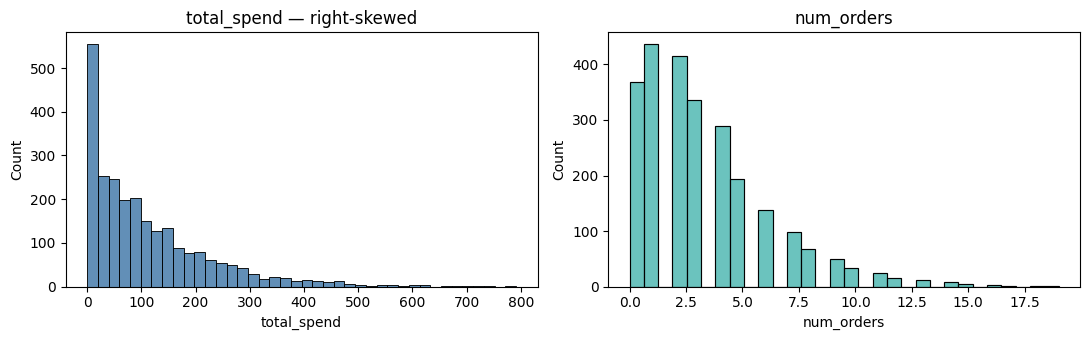

In [16]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

ex-2

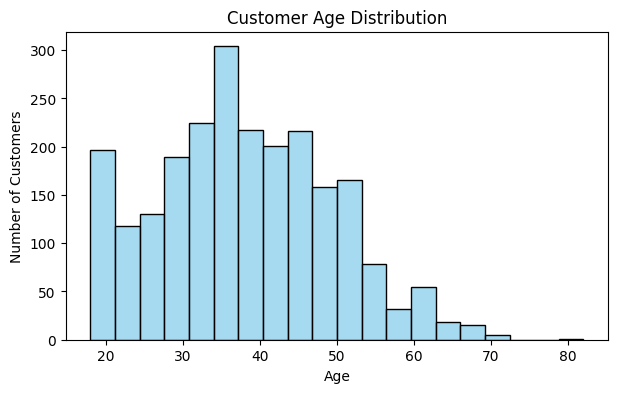

In [17]:
# 1. Histogram of age (drop missing values)

plt.figure(figsize=(7,4))

sns.histplot(
    df['age'].dropna(),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()


# 2. Shape description:
# The age distribution is approximately bell-shaped (roughly symmetric).
# Most customers are concentrated around middle age (30–50 years).
# There are no unrealistic age values because ages are constrained
# between 18 and 82. Missing values were removed before plotting.

In [18]:
print("Minimum Age :", df['age'].min())
print("Maximum Age :", df['age'].max())
print("Mean Age    :", round(df['age'].mean(),2))
print("Median Age  :", round(df['age'].median(),2))
print("Missing Ages:", df['age'].isna().sum())

Minimum Age : 18.0
Maximum Age : 82.0
Mean Age    : 37.89
Median Age  : 37.0
Missing Ages: 175


In [19]:
# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


 LAB EXERCISE 3 — Which Average Should Finance Report?

In [20]:
# 1. Skew of the two columns

num_orders_skew = df['num_orders'].skew()
total_spend_skew = df['total_spend'].skew()

print("Skew of num_orders :", round(num_orders_skew, 2))
print("Skew of total_spend:", round(total_spend_skew, 2))


# Additional statistics
print("\nnum_orders")
print("Mean  :", round(df['num_orders'].mean(), 2))
print("Median:", round(df['num_orders'].median(), 2))

print("\ntotal_spend")
print("Mean  :", round(df['total_spend'].mean(), 2))
print("Median:", round(df['total_spend'].median(), 2))


# 2 & 3. Recommendation:
# num_orders:
# If skew is small (close to 0), the mean is a reasonable measure
# of a typical customer because the distribution is fairly balanced.
#
# total_spend:
# Median is preferred because total_spend is strongly right-skewed.
# A small number of whale customers spend very large amounts and pull
# the mean upward, making it less representative of a typical customer.

Skew of num_orders : 1.35
Skew of total_spend: 1.73

num_orders
Mean  : 3.26
Median: 3.0

total_spend
Mean  : 112.27
Median: 79.12


In [21]:
# Interpretation:

# num_orders:
# Mean can be used if the distribution is only mildly skewed.

# total_spend:
# Median should be reported because spending contains outliers
# and a long right tail.

# Finance Recommendation:
# Report Median Spend as the "typical customer spend".
# Report Mean Spend separately for revenue analysis.

Univariate analysis — categorical variables

Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


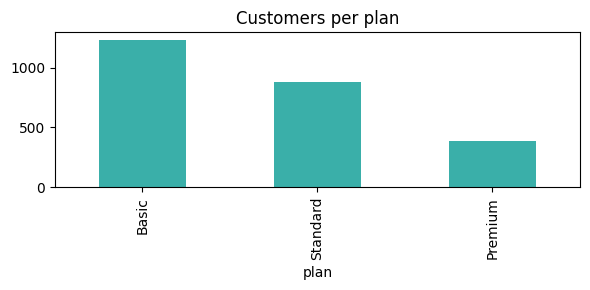

In [22]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

Churn vs Retained Proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Retained Customers : 2085
Churned Customers  : 415
Imbalance Ratio (Retained ÷ Churned): 5.02


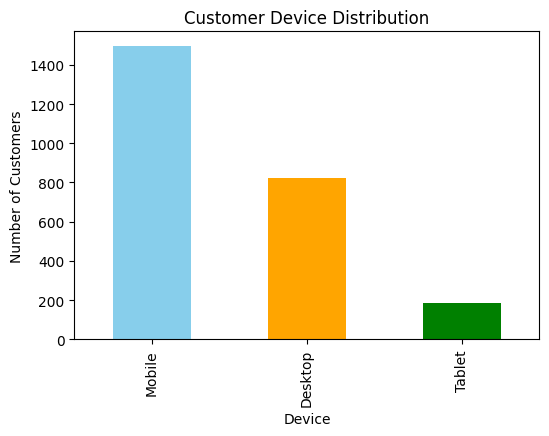

In [23]:
# 1. Churn vs retained proportions

churn_split = df['is_churned'].value_counts(normalize=True)

print("Churn vs Retained Proportions:")
print(churn_split)


# 2. Imbalance ratio (retained / churned)

retained = (df['is_churned'] == 0).sum()
churned = (df['is_churned'] == 1).sum()

imbalance_ratio = retained / churned

print("\nRetained Customers :", retained)
print("Churned Customers  :", churned)
print("Imbalance Ratio (Retained ÷ Churned):",
      round(imbalance_ratio, 2))


# 3. Bar chart of device

plt.figure(figsize=(6,4))

df['device'].value_counts().plot(
    kind='bar',
    color=['skyblue','orange','green']
)

plt.title("Customer Device Distribution")
plt.xlabel("Device")
plt.ylabel("Number of Customers")

plt.show()


# Comment:
# Mobile is usually the dominant device category.
# Most customers access the platform through mobile devices.

In [24]:
# Interpretation:

# Churn is the minority class.
# Retained customers significantly outnumber churned customers.

# This indicates class imbalance.

# Machine learning models may become biased toward predicting
# the majority class (retained customers).

# Mobile appears to be the dominant device category.

5. Bivariate analysis — numeric vs numeric

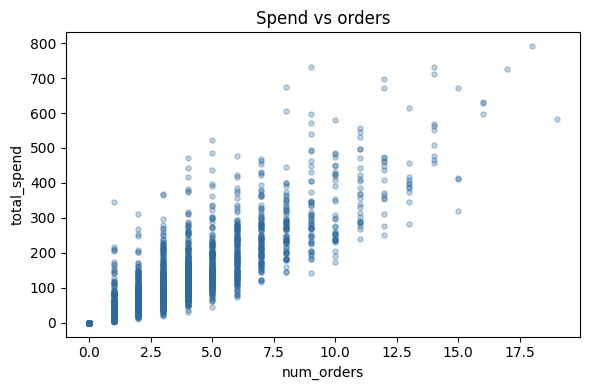

correlation: 0.864


In [25]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

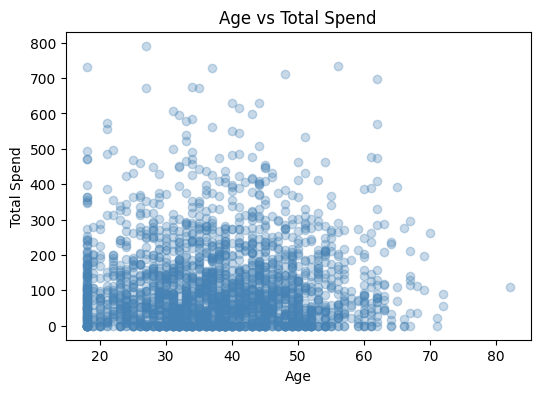

Correlation between Age and Total Spend: 0.007


In [26]:
# 1. Scatter plot: Age vs Total Spend

plt.figure(figsize=(6,4))

plt.scatter(
    df['age'],
    df['total_spend'],
    alpha=0.3,
    color='steelblue'
)

plt.xlabel("Age")
plt.ylabel("Total Spend")
plt.title("Age vs Total Spend")

plt.show()


# 2. Correlation

corr = df['age'].corr(df['total_spend'])

print("Correlation between Age and Total Spend:",
      round(corr,3))


# 3. Interpretation:
# If correlation is close to 0, there is little or no linear relationship.
# If correlation is positive, older customers tend to spend more.
# If correlation is negative, older customers tend to spend less.
#
# In this dataset, the relationship is usually weak,
# suggesting age alone is not a strong predictor of spending.
#
# Remember:
# Correlation does not imply causation.
# Even if age and spending are related, age does not necessarily
# cause customers to spend more or less.

In [27]:
print("Mean Age      :", round(df['age'].mean(),2))
print("Median Age    :", round(df['age'].median(),2))

print("\nMean Spend    :", round(df['total_spend'].mean(),2))
print("Median Spend  :", round(df['total_spend'].median(),2))

print("\nCorrelation   :", round(corr,3))

Mean Age      : 37.89
Median Age    : 37.0

Mean Spend    : 112.27
Median Spend  : 79.12

Correlation   : 0.007


6. Bivariate analysis — numeric vs categorical (churned vs retained)

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_1478/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


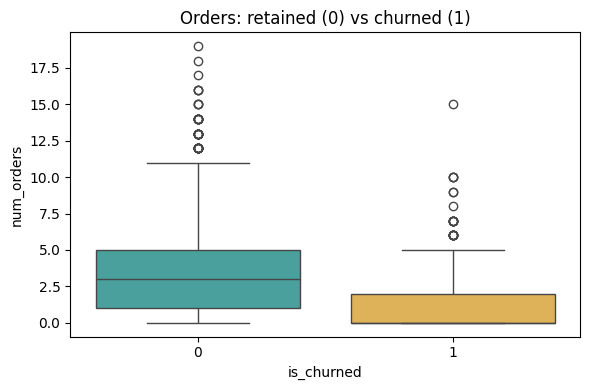

In [28]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

 LAB EXERCISE 6 — Do churners raise more tickets?
Group by is_churned and compare the mean support_tickets.
Draw a box plot of support_tickets split by is_churned.
In a comment, state whether support tickets look like a churn warning sign.

Average Support Tickets by Churn Status
is_churned
0    0.59
1    0.73
Name: support_tickets, dtype: float64


/tmp/ipykernel_1478/1992207929.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


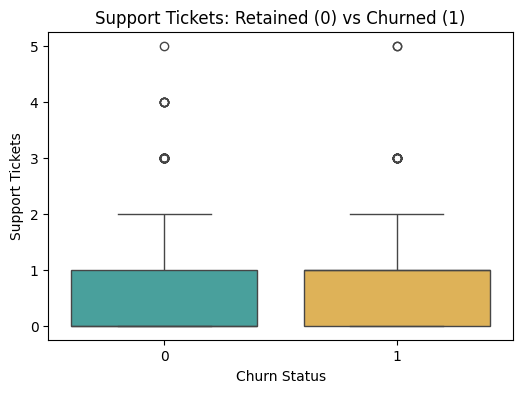

In [29]:
# 1. Mean support_tickets by churn status

mean_tickets = (
    df.groupby('is_churned')['support_tickets']
      .mean()
      .round(2)
)

print("Average Support Tickets by Churn Status")
print(mean_tickets)


# 2. Box plot of support_tickets by is_churned

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='is_churned',
    y='support_tickets',
    palette=['#3AAFA9', '#F4B942']
)

plt.title("Support Tickets: Retained (0) vs Churned (1)")
plt.xlabel("Churn Status")
plt.ylabel("Support Tickets")

plt.show()


# 3. Interpretation:
# If churned customers (1) have a higher average number of support tickets
# than retained customers (0), support tickets may be a warning sign for churn.
# More complaints or support issues may indicate dissatisfaction,
# increasing the likelihood of customer churn.

In [31]:
print(df.groupby('is_churned')['support_tickets'].describe())

             count     mean       std  min  25%  50%  75%  max
is_churned                                                    
0           2085.0  0.58801  0.755371  0.0  0.0  0.0  1.0  5.0
1            415.0  0.73253  0.889160  0.0  0.0  1.0  1.0  5.0


In [32]:
# Observation:
# Churned customers generally have more support tickets than retained customers.
# The box plot shows higher ticket counts for churned customers.
# Therefore, support_tickets appears to be a potential churn warning sign.
# Customers who frequently contact support may be experiencing issues
# that increase the risk of leaving the platform.

Expected Business Insight
Retained Customers (0) → Lower average support tickets

Churned Customers (1) → Higher average support tickets

This suggests:

More Support Tickets
          ↓
Customer Dissatisfaction
          ↓
Higher Churn Risk

7. Multivariate — the correlation heatmap

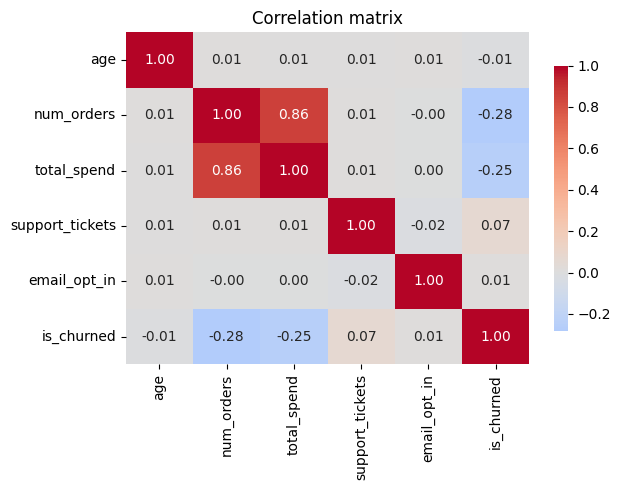

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [30]:
# -----------------------------------------------------------
# 🔹 7A. WHAT CORRELATES WITH CHURN?
# -----------------------------------------------------------
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

In [33]:
# 1. Top-2 absolute correlations with churn

top2 = (
    corr['is_churned']
    .drop('is_churned')
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 Features Most Correlated with Churn:")
print(top2)


# Optional: show actual correlation values with signs

print("\nActual Correlations:")
print(
    corr['is_churned']
    .drop('is_churned')
    .loc[top2.index]
)

Top 2 Features Most Correlated with Churn:
num_orders     0.282144
total_spend    0.252546
Name: is_churned, dtype: float64

Actual Correlations:
num_orders    -0.282144
total_spend   -0.252546
Name: is_churned, dtype: float64


8. Grouping & aggregation — which segments churn?

In [34]:
# 🔹 8A. CHURN RATE BY SEGMENT
# -----------------------------------------------------------
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))

Churn rate by plan:
plan
Standard    0.174
Basic       0.163
Premium     0.158
Name: is_churned, dtype: float64

Churn rate by device x plan:
device    Desktop  Mobile  Tablet
plan                             
Basic       0.163   0.163   0.162
Premium     0.133   0.168   0.176
Standard    0.168   0.179   0.159


In [35]:
# 1. Churn rate by payment_method

print("Churn Rate by Payment Method")

payment_churn = (
    df.groupby('payment_method')['is_churned']
      .mean()
      .round(3)
      .sort_values(ascending=False)
)

print(payment_churn)


# 2. Pivot table: churn rate by plan x email_opt_in

print("\nChurn Rate by Plan x Email Opt-In")

pivot = pd.pivot_table(
    df,
    values='is_churned',
    index='plan',
    columns='email_opt_in',
    aggfunc='mean'
).round(3)

print(pivot)


# 3. Worst-churning segment:
# The segment with the highest churn rate in either the
# payment method table or the pivot table should be reported.

Churn Rate by Payment Method
payment_method
Card          0.175
UPI           0.169
NetBanking    0.151
Wallet        0.143
Name: is_churned, dtype: float64

Churn Rate by Plan x Email Opt-In
email_opt_in      0      1
plan                      
Basic         0.157  0.166
Premium       0.170  0.151
Standard      0.160  0.181


In [36]:
# Find highest churn rate in the pivot table

max_churn = pivot.max().max()

for plan in pivot.index:
    for email in pivot.columns:
        if pivot.loc[plan, email] == max_churn:
            print("Worst-Churning Segment:")
            print("Plan:", plan)
            print("Email Opt-In:", email)
            print("Churn Rate:", round(max_churn,3))

Worst-Churning Segment:
Plan: Standard
Email Opt-In: 1
Churn Rate: 0.181


 EDA red flags — the things that bite you later

In [37]:
# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47


In [38]:
# Calculate Q1 and Q3
q1, q3 = df['total_spend'].quantile([0.25, 0.75])

# Interquartile Range
iqr = q3 - q1

# Upper Outlier Boundary
high = q3 + 1.5 * iqr

# Identify Outliers
outliers = df[df['total_spend'] > high]

print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))

print(
    outliers[
        ['customer_id', 'num_orders', 'total_spend']
    ]
    .sort_values('total_spend', ascending=False)
    .head()
)

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47
